# EDA for Store Item Demand Forecasting Dataset

Key Characteristics:
- Granularity: Daily sales
- Entities: 50 stores × 50 items
- Time span: 5 years (2019–2023)
- Observations: Store–item–day level

Features:
- date: Calendar date of the observation
- store_id: Unique store identifier
- item_id: Unique item identifier
- sales: Number of units sold on that day
- price: Item price (adjusted during promotions)
- promo: Promotion flag (1 = active, 0 = no promotion)
- weekday: Day of the week (0 = Monday, 6 = Sunday)
- month: Month of the year (1–12)

Questions to answer:

- Is there weekly seasonality?
- Is there yearly seasonality?
- Are there products with zero demand?
- Is demand highly volatile?

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
df_retail_sales = pd.read_csv('../dataset/retail_sales.csv')
df_retail_sales.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [4]:
df_retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [5]:
df_retail_sales.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [8]:
# --- Preprocessing ---
df_retail_sales['date'] = pd.to_datetime(df_retail_sales['date'])
df_daily = df_retail_sales.groupby('date')['sales'].sum().reset_index()

In [18]:
df_retail_sales_2013['promo'].value_counts()

promo
0    821453
1     91047
Name: count, dtype: int64

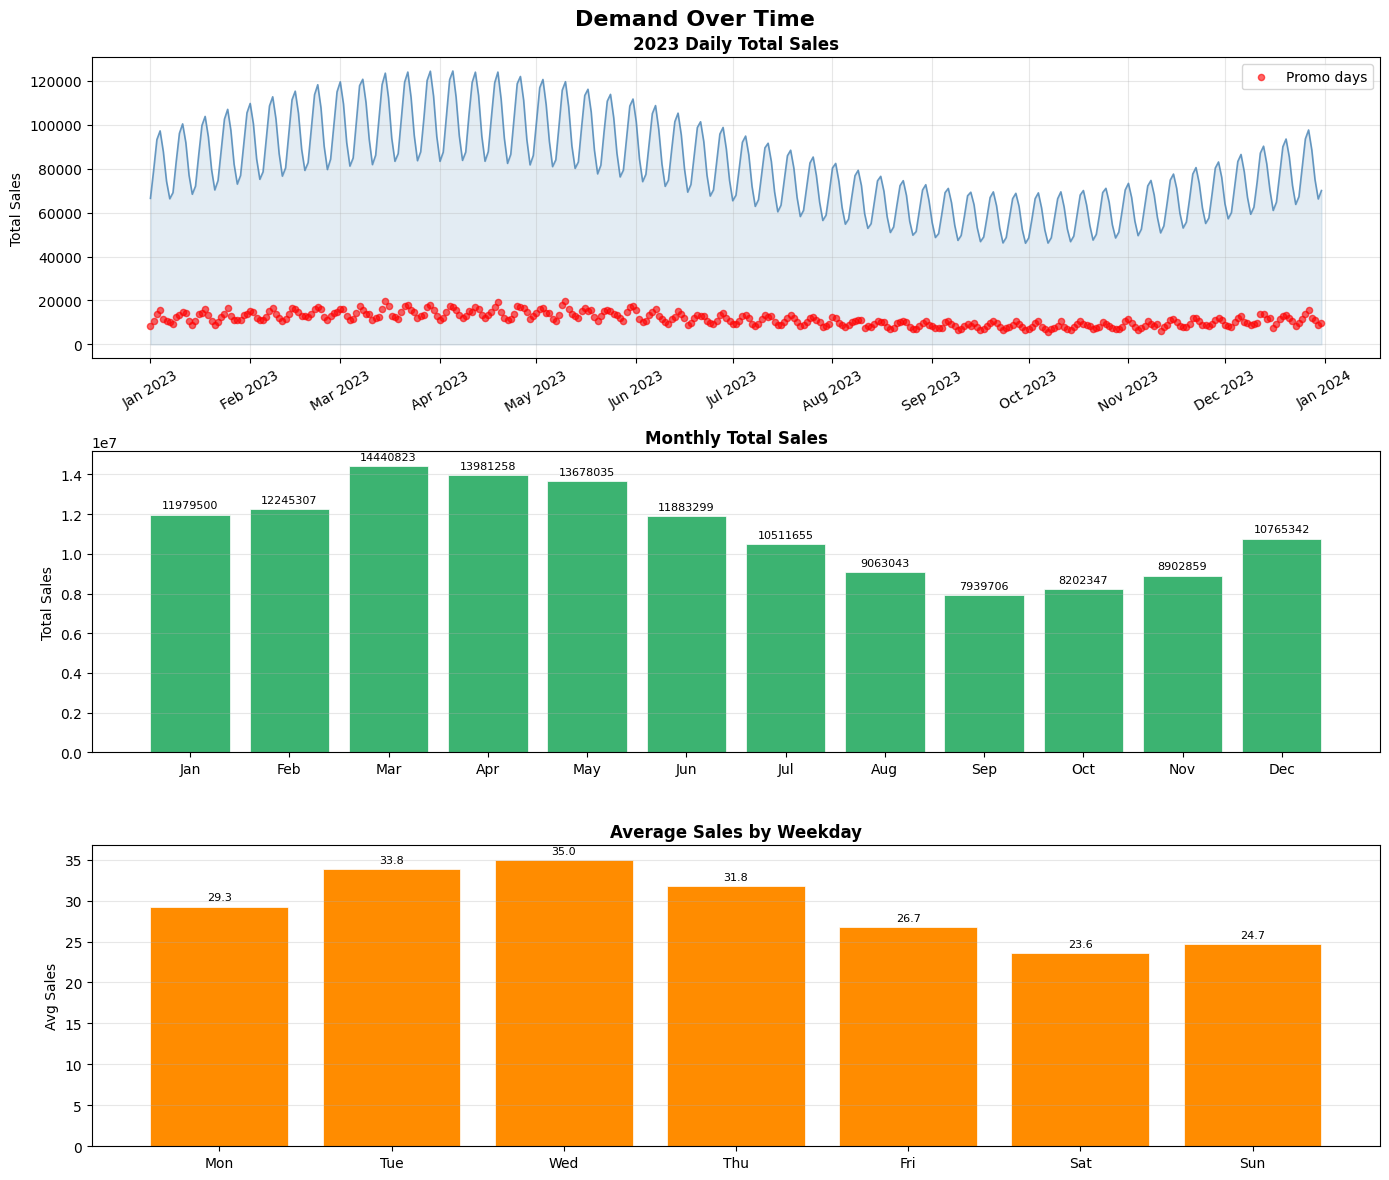

In [20]:
# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Demand Over Time', fontsize=16, fontweight='bold', y=0.98)

df_retail_sales_2023 = df_retail_sales[df_retail_sales['date'].dt.year == 2023]

# Aggregate to daily totals
df_daily_2023 = df_retail_sales_2023.groupby('date')['sales'].sum().reset_index()

# 1. Total daily demand
ax1 = axes[0]
ax1.plot(df_daily_2023['date'], df_daily_2023['sales'], color='steelblue', linewidth=1.2, alpha=0.8)
ax1.fill_between(df_daily_2023['date'], df_daily_2023['sales'], alpha=0.15, color='steelblue')
# Highlight promo days
promo_days = df_retail_sales_2023[df_retail_sales_2023['promo'] == 1].groupby('date')['sales'].sum().reset_index()
ax1.scatter(promo_days['date'], promo_days['sales'], color='red', s=20, zorder=5,
            label='Promo days', alpha=0.6)
ax1.set_title('2023 Daily Total Sales', fontweight='bold')
ax1.set_ylabel('Total Sales')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)


# 2. Monthly demand
df_monthly = df_retail_sales.groupby('month')['sales'].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_monthly['month_name'] = df_monthly['month'].apply(lambda x: month_names[x-1])
ax2 = axes[1]
bars = ax2.bar(df_monthly['month_name'], df_monthly['sales'],
               color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax2.bar_label(bars, fmt='%.0f', fontsize=8, padding=3)
ax2.set_title('Monthly Total Sales', fontweight='bold')
ax2.set_ylabel('Total Sales')
ax2.grid(True, alpha=0.3, axis='y')


# 3. Demand by weekday
df_weekday = df_retail_sales.groupby('weekday')['sales'].mean().reset_index()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_weekday['day_name'] = df_weekday['weekday'].apply(lambda x: day_names[x])
ax3 = axes[2]
bars3 = ax3.bar(df_weekday['day_name'], df_weekday['sales'],
                color='darkorange', edgecolor='white', linewidth=0.5)
ax3.bar_label(bars3, fmt='%.1f', fontsize=8, padding=3)
ax3.set_title('Average Sales by Weekday', fontweight='bold')
ax3.set_ylabel('Avg Sales')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()